In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os

In [3]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, 4),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root='/data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='/data', train=False, download=True, transform=train_transform
)

train_size = int(0.9 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
test_size = len(test_dataset)

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_dataloader = DataLoader(train_dataset, batch_size=64, num_workers=2, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size = 64, shuffle = False, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle = False, num_workers=2)

model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)



In [4]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(total_params)
print(trainable_params)


11689512
513000


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr = 0.001)

def train_epoch(model, loader, criterion, optimizer, device):
    model.to(device)
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, 100 * correct/total

def validate_epoch(model, loader, criterion, device):
    model.to(device)
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, 100 * correct/total


In [6]:
n_epochs = 15
best_val_acc = 0.0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

model.to(device)

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(model,train_dataloader,criterion,optimizer,device)
    val_loss, val_acc = validate_epoch(model,val_dataloader,criterion,device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs('checkpoints', exist_ok = True)
        torch.save(model.state_dict(), 'checkpoints/best_resnet.pth')
        save_msg = 'saved'
    else:
        save_msg = ''

    print(f'epoch {epoch+1:2d} / {n_epochs}')
    print(f'train loss {train_loss} acc {train_acc}')
    print(f'val loss {val_loss} acc {val_acc}')

print('done lol ')


epoch  1 / 15
train loss 2.583531611251831 acc 27.166666666666668
val loss 1.8308385818481445 acc 37.74
epoch  2 / 15
train loss 1.7790155328114827 acc 37.71111111111111
val loss 1.733408681869507 acc 40.84
epoch  3 / 15
train loss 1.7267592491997612 acc 39.45333333333333
val loss 1.7063335920333862 acc 41.28
epoch  4 / 15
train loss 1.7162729724884034 acc 39.78666666666667
val loss 1.699818635559082 acc 39.4
epoch  5 / 15
train loss 1.7026011374579535 acc 40.23555555555556
val loss 1.693193409729004 acc 41.28
epoch  6 / 15
train loss 1.7039963580873279 acc 40.32222222222222
val loss 1.6882145496368408 acc 41.1
epoch  7 / 15
train loss 1.7056532616085476 acc 40.08222222222222
val loss 1.6676300832748414 acc 41.38
epoch  8 / 15
train loss 1.7052696742587619 acc 40.291111111111114
val loss 1.704642827796936 acc 41.1
epoch  9 / 15
train loss 1.696814341184828 acc 40.63333333333333
val loss 1.6920075904846192 acc 41.22
epoch 10 / 15
train loss 1.696760576163398 acc 40.757777777777775
val l

In [ ]:
print('test')
model.load_state_dict(torch.load('checkpoints/best_resnet.pth'))
test_loss, test_acc = validate_epoch(model, test_dataloader, criterion, device)
print(test_loss, '', test_acc)

In [7]:
torch.cuda.is_available()

True

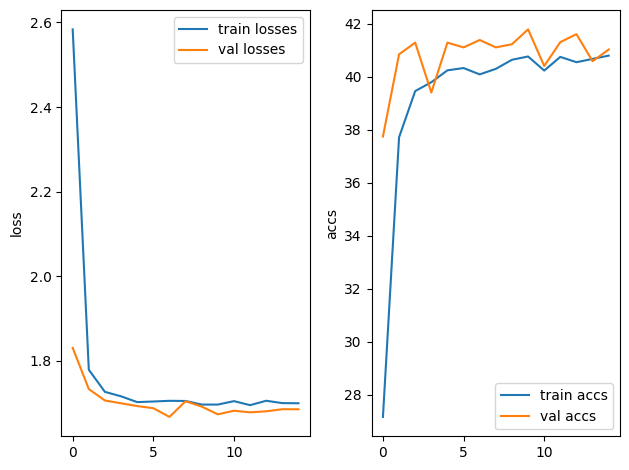

In [13]:
plt.Figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(train_losses, label = 'train losses')
plt.plot(val_losses, label = 'val losses')
plt.ylabel('loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label = 'train accs')
plt.plot(val_accs, label = 'val accs')
plt.ylabel('accs')
plt.legend()
plt.tight_layout()
plt.show()